In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def _sample_sigma(rng, sigma_or_range):
    if isinstance(sigma_or_range, (tuple, list, np.ndarray)):
        return rng.uniform(float(sigma_or_range[0]), float(sigma_or_range[1]))
    return float(sigma_or_range)


def _sample_duration_perturbation(rng, std, lower=-0.95):
    for _ in range(100):
        x = rng.normal(0.0, std)
        if x > lower:
            return x
    return lower


def _check_positive_int(name, value, allow_zero=False):
    if allow_zero:
        if not isinstance(value, int) or value < 0:
            raise ValueError(f"{name} must be a nonnegative integer.")
    else:
        if not isinstance(value, int) or value <= 0:
            raise ValueError(f"{name} must be a positive integer.")


# Training workload

def training_phase(
    T=10.0,
    Fs=100,
    F=(0.5, 1.5),
    up_ratio=(0.55, 0.80),
    p_hat_tr=1.0,
    sigma_xi=0.1,
    sigma_delta=0.05,
    mu_delta=0.3,
    sigma_eta_up=(0.02, 0.05),
    sigma_eta_down=(0.01, 0.03),
    seed=None,
    return_info=False,
):

    _check_positive_int("Fs", Fs)

    rng = np.random.default_rng(seed)
    N = int(round(T * Fs))

    if N <= 0:
        raise ValueError("T * Fs must be positive.")

    power = np.zeros(N)

    f0 = rng.uniform(*F)

    sig_eta_up = _sample_sigma(rng, sigma_eta_up)
    sig_eta_down = _sample_sigma(rng, sigma_eta_down)

    cycle_info = []
    i = 0

    while i < N:
        xi_i = _sample_duration_perturbation(rng, sigma_xi)

        T_cycle = 1.0 / (f0 * (1.0 + xi_i))
        n_cycle = max(2, int(round(T_cycle * Fs)))

        r_i = rng.uniform(*up_ratio)

        n_up = int(round(r_i * n_cycle))
        n_up = min(max(1, n_up), n_cycle - 1)
        n_down = n_cycle - n_up

        cycle_start_idx = i

        len_up = min(n_up, N - i)

        delta_up_i = rng.normal(0.0, sigma_delta)
        eta_up = rng.normal(0.0, sig_eta_up, len_up)

        power[i:i + len_up] = p_hat_tr * (1.0 + delta_up_i + eta_up)
        i += len_up

        if i >= N:
            cycle_info.append(
                {
                    "cycle_start_idx": cycle_start_idx,
                    "xi": xi_i,
                    "r": r_i,
                    "n_up": len_up,
                    "n_down": 0,
                    "delta_up": delta_up_i,
                    "delta_down": None,
                }
            )
            break

        len_down = min(n_down, N - i)

        delta_down_i = rng.normal(mu_delta, sigma_delta)
        eta_down = rng.normal(0.0, sig_eta_down, len_down)

        power[i:i + len_down] = p_hat_tr * (1.0 - delta_down_i + eta_down)
        i += len_down

        cycle_info.append(
            {
                "cycle_start_idx": cycle_start_idx,
                "xi": xi_i,
                "r": r_i,
                "n_up": len_up,
                "n_down": len_down,
                "delta_up": delta_up_i,
                "delta_down": delta_down_i,
            }
        )

    power = np.clip(power, 0.0, None)

    if return_info:
        info = {
            "f0": f0,
            "sigma_eta_up": sig_eta_up,
            "sigma_eta_down": sig_eta_down,
            "cycle_info": cycle_info,
        }
        return power, info

    return power


def finetuning_phase(
    T=10.0,
    Fs=100,
    F=(0.3, 0.7),
    tail_ratio=(0.70, 0.90),
    p_hat_ft=1.0,
    sigma_zeta=0.1,
    sigma_delta=0.03,
    mu_delta=0.8,
    sigma_eta_tail=(0.01, 0.03),
    sigma_eta_idle=(0.005, 0.02),
    seed=None,
    return_info=False,
):

    _check_positive_int("Fs", Fs)

    rng = np.random.default_rng(seed)
    N = int(round(T * Fs))

    if N <= 0:
        raise ValueError("T * Fs must be positive.")

    power = np.zeros(N)

    f1 = rng.uniform(*F)

    sig_eta_tail = _sample_sigma(rng, sigma_eta_tail)
    sig_eta_idle = _sample_sigma(rng, sigma_eta_idle)

    cycle_info = []
    i = 0

    while i < N:
        zeta_i = _sample_duration_perturbation(rng, sigma_zeta)

        T_cycle = 1.0 / (f1 * (1.0 + zeta_i))
        n_cycle = max(2, int(round(T_cycle * Fs)))

        r_i = rng.uniform(*tail_ratio)

        n_tail = int(round(r_i * n_cycle))
        n_tail = min(max(1, n_tail), n_cycle - 1)
        n_idle = n_cycle - n_tail

        cycle_start_idx = i

        len_tail = min(n_tail, N - i)

        delta_tail_i = rng.normal(0.0, sigma_delta)
        eta_tail = rng.normal(0.0, sig_eta_tail, len_tail)

        power[i:i + len_tail] = p_hat_ft * (1.0 + delta_tail_i + eta_tail)
        i += len_tail

        if i >= N:
            cycle_info.append(
                {
                    "cycle_start_idx": cycle_start_idx,
                    "zeta": zeta_i,
                    "r": r_i,
                    "n_tail": len_tail,
                    "n_idle": 0,
                    "delta_tail": delta_tail_i,
                    "delta_idle": None,
                }
            )
            break

        len_idle = min(n_idle, N - i)

        delta_idle_i = rng.normal(mu_delta, sigma_delta)
        eta_idle = rng.normal(0.0, sig_eta_idle, len_idle)

        power[i:i + len_idle] = p_hat_ft * (1.0 - delta_idle_i + eta_idle)
        i += len_idle

        cycle_info.append(
            {
                "cycle_start_idx": cycle_start_idx,
                "zeta": zeta_i,
                "r": r_i,
                "n_tail": len_tail,
                "n_idle": len_idle,
                "delta_tail": delta_tail_i,
                "delta_idle": delta_idle_i,
            }
        )

    power = np.clip(power, 0.0, None)

    if return_info:
        info = {
            "f1": f1,
            "sigma_eta_tail": sig_eta_tail,
            "sigma_eta_idle": sig_eta_idle,
            "cycle_info": cycle_info,
        }
        return power, info

    return power

In [12]:
def _generate_with_random_start(
    generator_func,
    T,
    Fs,
    max_start_time,
    rng,
    return_info=False,
    **kwargs,
):

    N = int(round(T * Fs))

    if N <= 0:
        raise ValueError("T * Fs must be positive.")

    max_start_time = float(max_start_time)

    if max_start_time < 0:
        raise ValueError("max_start_time must be nonnegative.")

    max_start_time = min(max_start_time, float(T))

    start_time = rng.uniform(0.0, max_start_time)
    start_idx = int(round(start_time * Fs))
    start_idx = min(max(start_idx, 0), N)

    workload = np.zeros(N)

    if start_idx >= N:
        if return_info:
            return workload, {
                "start_time": start_time,
                "start_idx": start_idx,
                "active_info": None,
            }
        return workload, start_time

    remaining_T = (N - start_idx) / Fs

    if return_info:
        active_part, active_info = generator_func(
            T=remaining_T,
            Fs=Fs,
            seed=rng.integers(0, 2**32 - 1),
            return_info=True,
            **kwargs,
        )
    else:
        active_part = generator_func(
            T=remaining_T,
            Fs=Fs,
            seed=rng.integers(0, 2**32 - 1),
            **kwargs,
        )
        active_info = None

    workload[start_idx:] = active_part[:N - start_idx]

    if return_info:
        return workload, {
            "start_time": start_time,
            "start_idx": start_idx,
            "active_info": active_info,
        }

    return workload, start_time


def aggregated_ai_workload(
    T=10.0,
    Fs=100,
    total_ai_nominal=1.0,
    large_training_ratio=0.90,
    small_training_total_ratio=0.0,
    finetuning_total_ratio=0.1,
    Ntr=0,
    Nft=1,
    max_start_time=2.0,
    seed=None,
    return_components=False,
):

    _check_positive_int("Fs", Fs)
    _check_positive_int("Ntr", Ntr, allow_zero=True)
    _check_positive_int("Nft", Nft, allow_zero=True)

    ratio_sum = (
        float(large_training_ratio)
        + float(small_training_total_ratio)
        + float(finetuning_total_ratio)
    )

    if not np.isclose(ratio_sum, 1.0):
        raise ValueError(
            "The workload nominal ratios must sum to 1. "
            f"Current sum = {ratio_sum:.6f}"
        )

    rng = np.random.default_rng(seed)
    N = int(round(T * Fs))

    if N <= 0:
        raise ValueError("T * Fs must be positive.")

    p_large = total_ai_nominal * large_training_ratio
    p_small_total = total_ai_nominal * small_training_total_ratio
    p_ft_total = total_ai_nominal * finetuning_total_ratio

    p_small_each = p_small_total / Ntr if Ntr > 0 else 0.0
    p_ft_each = p_ft_total / Nft if Nft > 0 else 0.0

    P_AI = np.zeros(N)

    components = {
        "large_training": None,
        "small_training": [],
        "fine_tuning": [],
        "start_times": {
            "large_training": None,
            "small_training": [],
            "fine_tuning": [],
        },
        "metadata": {
            "T": T,
            "Fs": Fs,
            "total_ai_nominal": total_ai_nominal,
            "large_training_ratio": large_training_ratio,
            "small_training_total_ratio": small_training_total_ratio,
            "finetuning_total_ratio": finetuning_total_ratio,
            "Ntr": Ntr,
            "Nft": Nft,
            "max_start_time": max_start_time,
            "p_large": p_large,
            "p_small_each": p_small_each,
            "p_ft_each": p_ft_each,
        },
        "workload_info": {
            "large_training": None,
            "small_training": [],
            "fine_tuning": [],
        },
    }

    large_training, large_info = _generate_with_random_start(
        generator_func=training_phase,
        T=T,
        Fs=Fs,
        max_start_time=max_start_time,
        rng=rng,
        p_hat_tr=p_large,
        return_info=True,
    )

    P_AI += large_training

    components["large_training"] = large_training
    components["start_times"]["large_training"] = large_info["start_time"]
    components["workload_info"]["large_training"] = large_info


    for _ in range(Ntr):
        w, info = _generate_with_random_start(
            generator_func=training_phase,
            T=T,
            Fs=Fs,
            max_start_time=max_start_time,
            rng=rng,
            p_hat_tr=p_small_each,
            return_info=True,
        )

        P_AI += w

        components["small_training"].append(w)
        components["start_times"]["small_training"].append(info["start_time"])
        components["workload_info"]["small_training"].append(info)

    for _ in range(Nft):
        w, info = _generate_with_random_start(
            generator_func=finetuning_phase,
            T=T,
            Fs=Fs,
            max_start_time=max_start_time,
            rng=rng,
            p_hat_ft=p_ft_each,
            return_info=True,
        )

        P_AI += w

        components["fine_tuning"].append(w)
        components["start_times"]["fine_tuning"].append(info["start_time"])
        components["workload_info"]["fine_tuning"].append(info)

    P_AI = np.clip(P_AI, 0.0, None)

    if return_components:
        return P_AI, components

    return P_AI


def datacenter_load_profile(
    T=10.0,
    Fs=100,
    datacenter_capacity=1.0,
    steady_component_ratio=0.40,
    fluctuating_component_ratio=0.60,
    max_start_time=2.0,
    P_AI=P_AI,
    components=components,
    seed=None,
    return_components=False,
):

    ratio_sum = steady_component_ratio + fluctuating_component_ratio

    if not np.isclose(ratio_sum, 1.0):
        raise ValueError(
            "steady_component_ratio + fluctuating_component_ratio must be 1."
        )

    N = int(round(T * Fs))

    P_steady = np.ones(N) * datacenter_capacity * steady_component_ratio
    P_DC = P_steady + P_AI

    if return_components:
        components["P_steady"] = P_steady
        components["P_AI"] = P_AI
        components["P_DC"] = P_DC
        components["metadata"]["datacenter_capacity"] = datacenter_capacity
        components["metadata"]["steady_component_ratio"] = steady_component_ratio
        components["metadata"]["fluctuating_component_ratio"] = fluctuating_component_ratio
        return P_DC, components

    return P_DC

In [4]:
def _sum_component_list(component_list, N):
    if len(component_list) == 0:
        return np.zeros(N)
    return np.sum(np.vstack(component_list), axis=0)


def _single_sided_fft(x, Fs, remove_mean=True):
    x = np.asarray(x)

    if remove_mean:
        x = x - np.mean(x)

    N = len(x)
    freq = np.fft.rfftfreq(N, d=1.0 / Fs)
    amp = np.abs(np.fft.rfft(x)) / N
    amp[1:-1] *= 2.0

    return freq, amp


def plot_ai_workload_components(P_AI, components, Fs=100, show_start_times=True):
    N = len(P_AI)
    t = np.arange(N) / Fs

    large_training = components["large_training"]
    small_training_sum = _sum_component_list(components["small_training"], N)
    fine_tuning_sum = _sum_component_list(components["fine_tuning"], N)

    fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)

    axes[0].plot(t, large_training)
    axes[0].set_ylabel("Large tr.")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, small_training_sum)
    axes[1].set_ylabel("Small tr.")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, fine_tuning_sum)
    axes[2].set_ylabel("Fine-tuning")
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(t, P_AI)
    axes[3].set_ylabel(r"$P_{\mathrm{AI}}(t)$")
    axes[3].set_xlabel("Time [s]")
    axes[3].grid(True, alpha=0.3)

    if show_start_times:
        st = components["start_times"]

        for ax in axes:
            if st["large_training"] is not None:
                ax.axvline(st["large_training"], linestyle="--", linewidth=1.0)

            for tau in st["small_training"]:
                ax.axvline(tau, linestyle=":", linewidth=1.0)

            for tau in st["fine_tuning"]:
                ax.axvline(tau, linestyle="-.", linewidth=1.0)

    fig.suptitle("Aggregated AI Workload Components")
    fig.tight_layout()
    plt.show()


def plot_ai_workload_fft(P_AI, components, Fs=100, fmax=5.0):
    N = len(P_AI)

    large_training = components["large_training"]
    small_training_sum = _sum_component_list(components["small_training"], N)
    fine_tuning_sum = _sum_component_list(components["fine_tuning"], N)

    signals = {
        "Large training": large_training,
        "Small training sum": small_training_sum,
        "Fine-tuning sum": fine_tuning_sum,
        "Aggregated AI workload": P_AI,
    }

    fig, ax = plt.subplots(figsize=(11, 4.5))

    for label, sig in signals.items():
        freq, amp = _single_sided_fft(sig, Fs, remove_mean=True)
        idx = freq <= fmax
        ax.plot(freq[idx], amp[idx], label=label)

    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("FFT amplitude")
    ax.set_title("FFT Analysis of AI Workload")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()


def plot_datacenter_load(P_DC, components, Fs=100):

    N = len(P_DC)
    t = np.arange(N) / Fs

    P_steady = components["P_steady"]
    P_AI = components["P_AI"]

    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)

    axes[0].plot(t, P_steady)
    axes[0].set_ylabel(r"$P_{\mathrm{steady}}$")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, P_AI)
    axes[1].set_ylabel(r"$P_{\mathrm{AI}}(t)$")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, P_DC)
    axes[2].set_ylabel(r"$P_{\mathrm{DC}}(t)$")
    axes[2].set_xlabel("Time [s]")
    axes[2].grid(True, alpha=0.3)

    fig.suptitle("Datacenter Load Profile")
    fig.tight_layout()
    plt.show()


def plot_datacenter_fft(P_DC, components, Fs=100, fmax=5.0):

    P_AI = components["P_AI"]

    freq_ai, amp_ai = _single_sided_fft(P_AI, Fs, remove_mean=True)
    freq_dc, amp_dc = _single_sided_fft(P_DC, Fs, remove_mean=True)

    idx_ai = freq_ai <= fmax
    idx_dc = freq_dc <= fmax

    fig, ax = plt.subplots(figsize=(11, 4.5))

    ax.plot(freq_ai[idx_ai], amp_ai[idx_ai], label=r"$P_{\mathrm{AI}}(t)$")
    ax.plot(freq_dc[idx_dc], amp_dc[idx_dc], label=r"$P_{\mathrm{DC}}(t)$")

    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("FFT amplitude")
    ax.set_title("FFT Analysis of Datacenter Load")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()
    plt.show()

## Hyperscale AI Datacenter Workload
### Dominant single large training, small nubmer of small training & finetuning

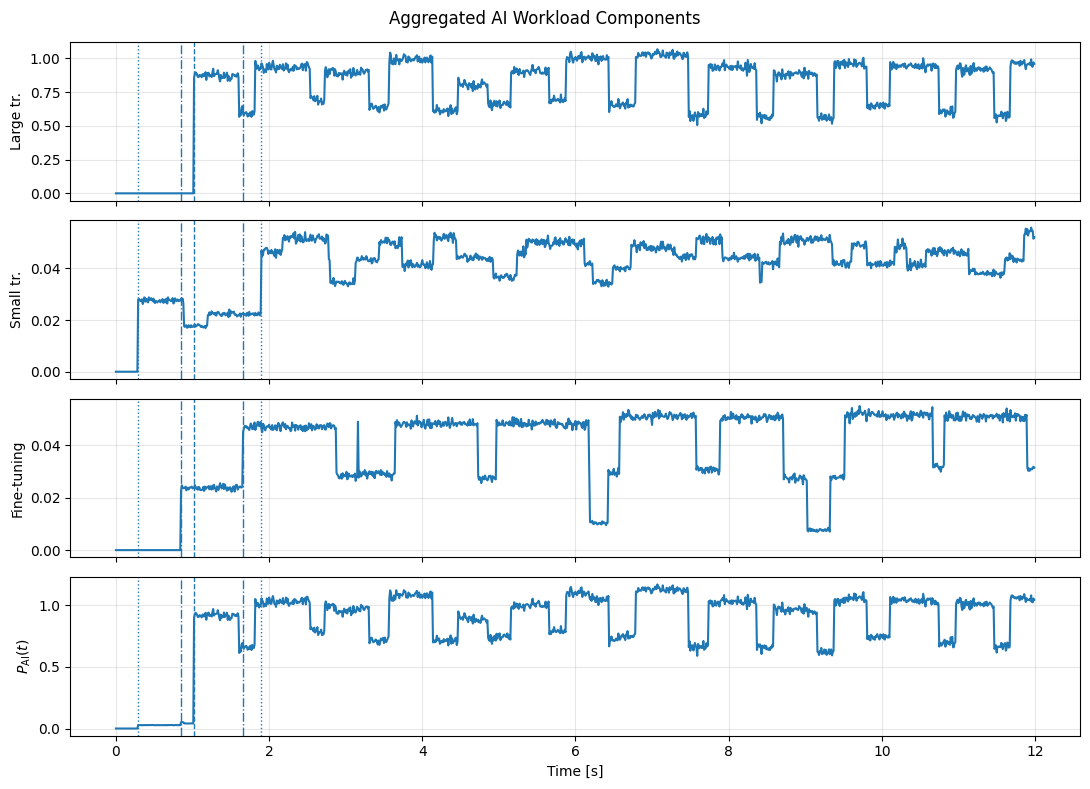

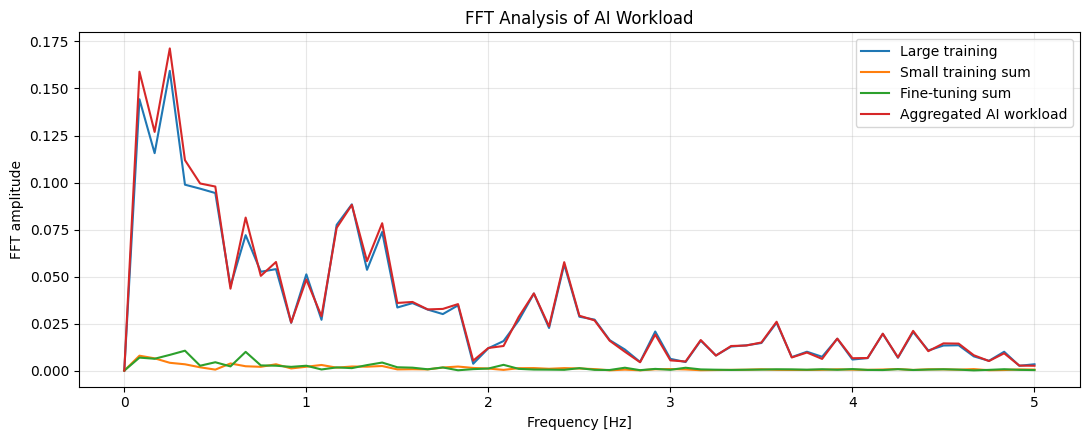

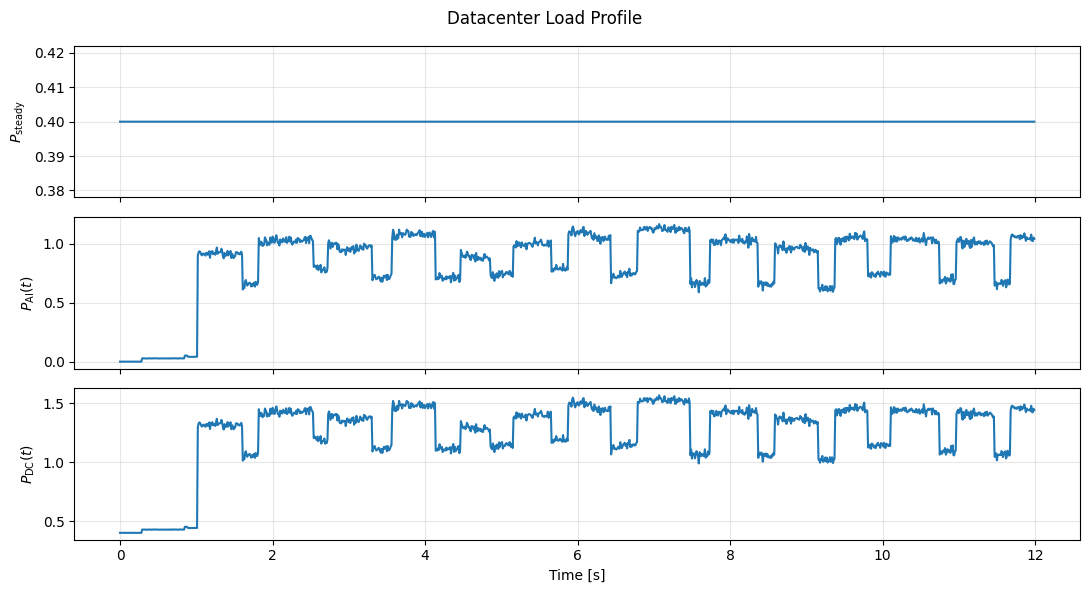

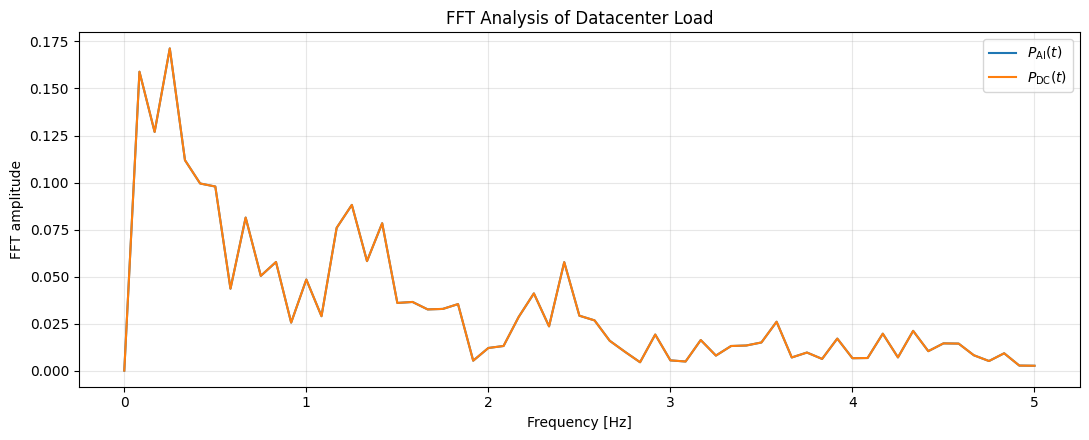

In [13]:
T = 12.0
Fs = 100
seed = 1

P_AI, components = aggregated_ai_workload(
    T=T,
    Fs=Fs,
    total_ai_nominal=1.0,
    large_training_ratio=0.90,
    small_training_total_ratio=0.05,
    finetuning_total_ratio=0.05,
    Ntr=2,
    Nft=2,
    max_start_time=2.0,
    seed=seed,
    return_components=True,
)


plot_ai_workload_components(
    P_AI=P_AI,
    components=components,
    Fs=Fs,
    show_start_times=True,
)

plot_ai_workload_fft(
    P_AI=P_AI,
    components=components,
    Fs=Fs,
    fmax=5.0,
)


P_DC, dc_components = datacenter_load_profile(
    T=T,
    Fs=Fs,
    datacenter_capacity=1.0,
    steady_component_ratio=0.40,
    fluctuating_component_ratio=0.60,
    P_AI=P_AI,
    components=components,
    max_start_time=2.0,
    seed=seed,
    return_components=True,
)

plot_datacenter_load(
    P_DC=P_DC,
    components=dc_components,
    Fs=Fs,
)

plot_datacenter_fft(
    P_DC=P_DC,
    components=dc_components,
    Fs=Fs,
    fmax=5.0,
)

## No large training workload and large nubmer of small training and fine-tuning workloads
### Can imitate the current datacenter's behavior

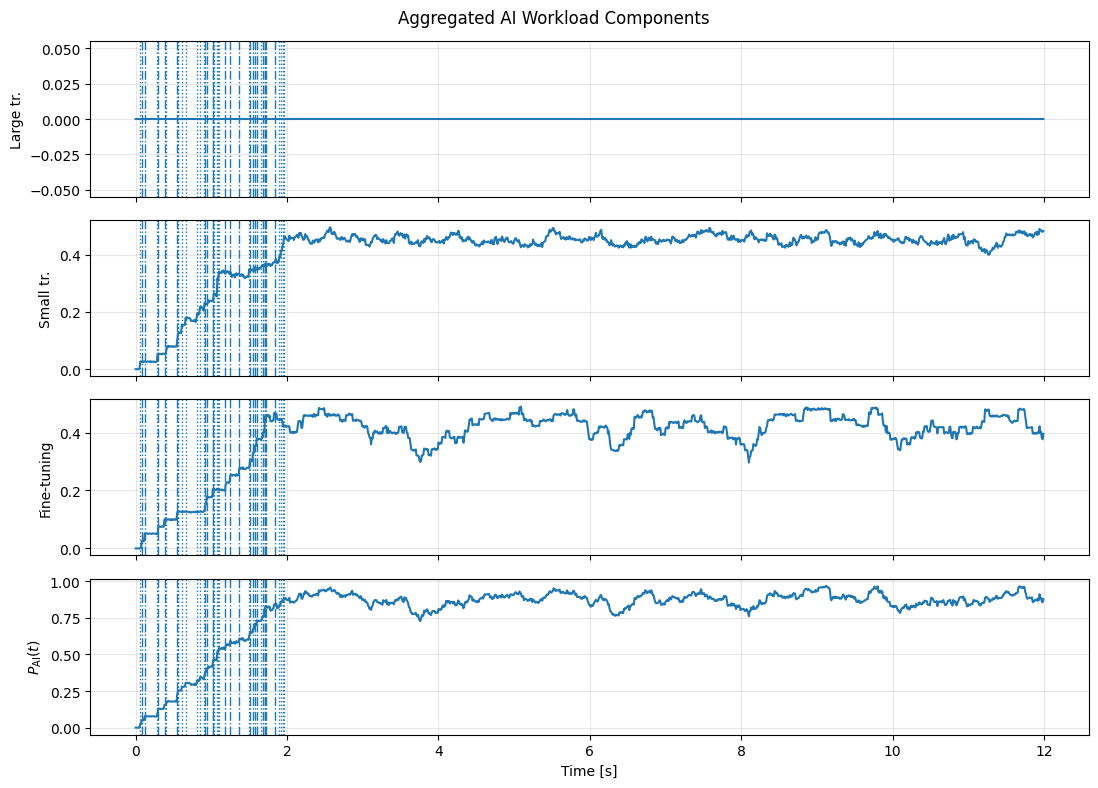

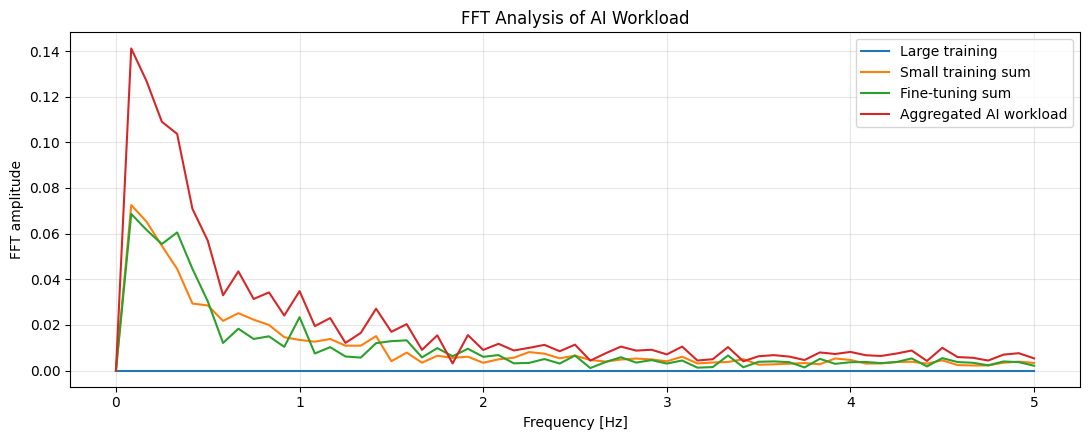

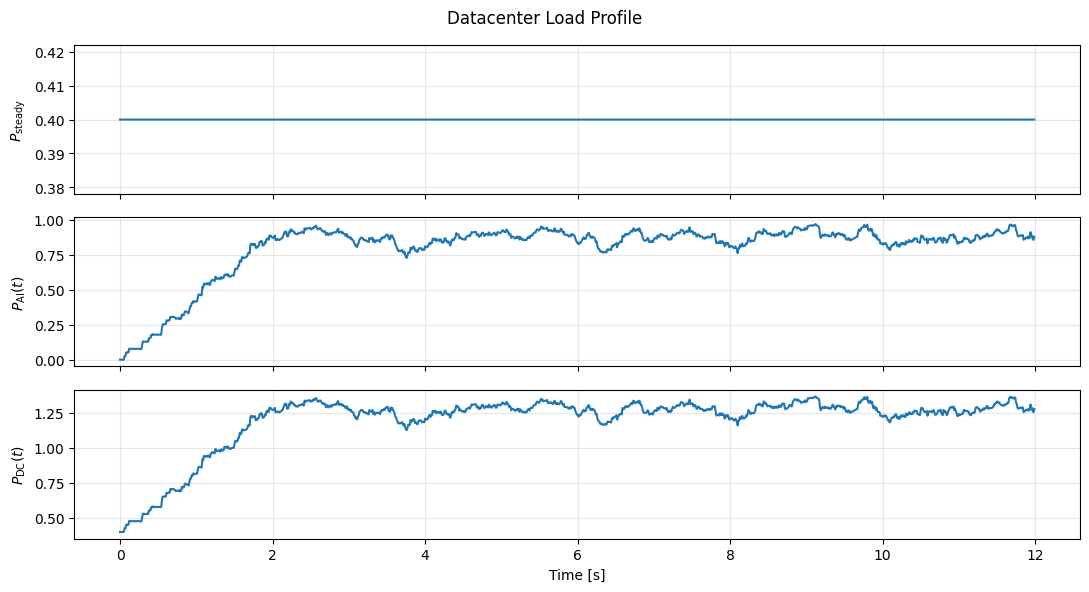

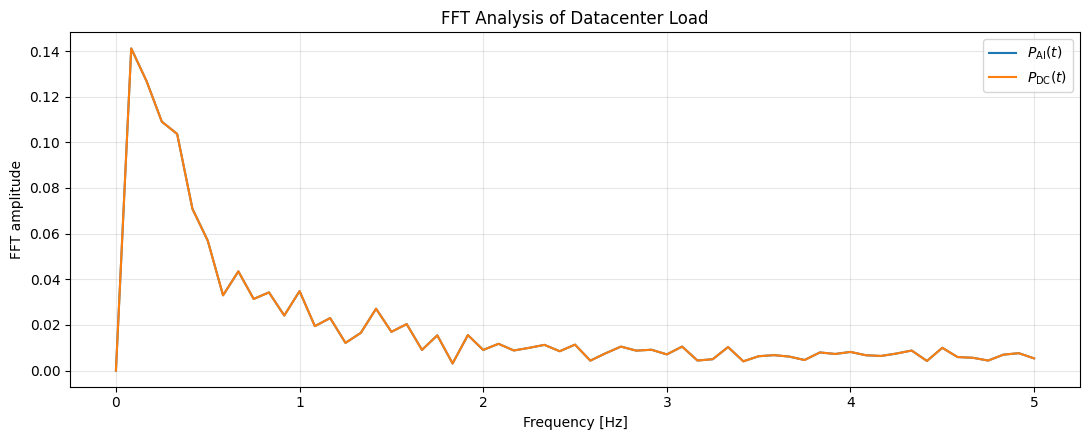

In [14]:
T = 12.0
Fs = 100
seed = 1

P_AI, components = aggregated_ai_workload(
    T=T,
    Fs=Fs,
    total_ai_nominal=1.0,
    large_training_ratio=0.00,
    small_training_total_ratio=0.50,
    finetuning_total_ratio=0.50,
    Ntr=20,
    Nft=20,
    max_start_time=2.0,
    seed=seed,
    return_components=True,
)


plot_ai_workload_components(
    P_AI=P_AI,
    components=components,
    Fs=Fs,
    show_start_times=True,
)

plot_ai_workload_fft(
    P_AI=P_AI,
    components=components,
    Fs=Fs,
    fmax=5.0,
)

P_DC, dc_components = datacenter_load_profile(
    T=T,
    Fs=Fs,
    datacenter_capacity=1.0,
    steady_component_ratio=0.40,
    fluctuating_component_ratio=0.60,
    max_start_time=2.0,
    P_AI=P_AI,
    components=components,
    seed=seed,
    return_components=True,
)

plot_datacenter_load(
    P_DC=P_DC,
    components=dc_components,
    Fs=Fs,
)

plot_datacenter_fft(
    P_DC=P_DC,
    components=dc_components,
    Fs=Fs,
    fmax=5.0,
)